(60000, 784) (10000, 784)
(784,) (784,)
(784,) (784,)
Variance ratio with 2 components: [0.29033506 0.17757271]
Total variance preserved: 0.4679078
shape from 75% variance: (60000, 14)
shape from 95% variance: (60000, 188)
shape from 99% variance: (60000, 459)


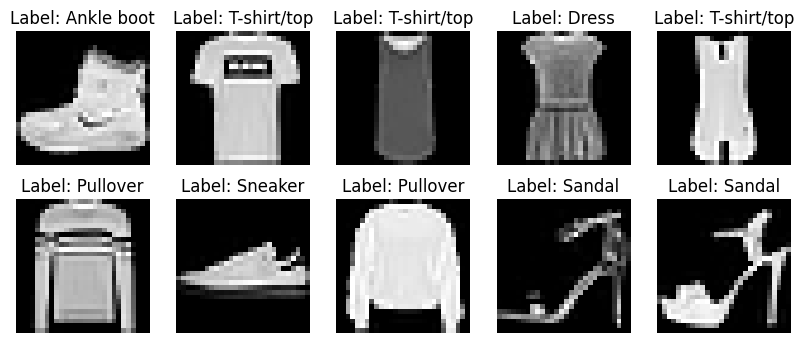

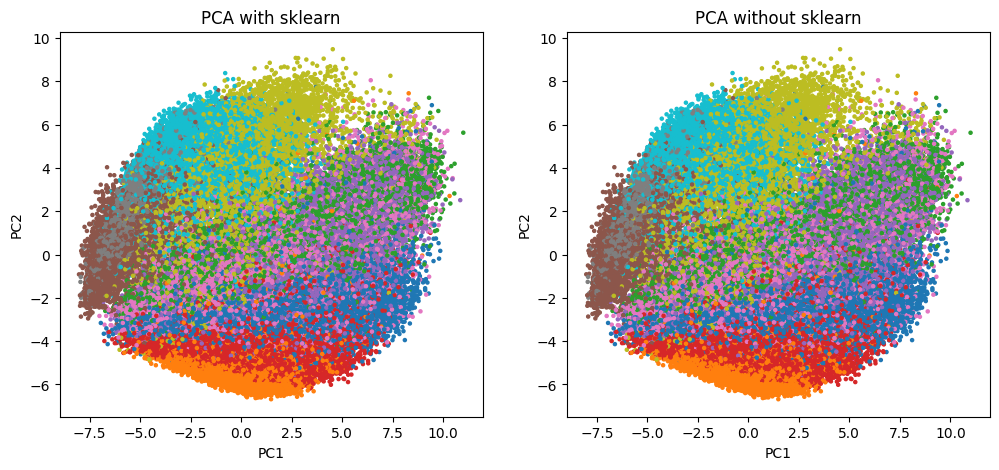

In [ ]:
# Principal component analysis (PCA)

# 1- Load or create a dataset with more than 2 dimensions.

import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


np.random.seed(42)

(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data() # Load Fashion-MNIST dataset /784 dimensions

X_train = x_train.reshape(-1, 28*28).astype(np.float32) / 255.0 # Normalizing the data
X_test  = x_test.reshape(-1, 28*28).astype(np.float32) / 255.0

print(X_train.shape, X_test.shape)

lbls = {0: 'T-shirt/top', 1: 'Trouser', 2: 'Pullover', 3: 'Dress', 4: 'Coat',
        5: 'Sandal', 6: 'Shirt', 7: 'Sneaker', 8: 'Bag', 9: 'Ankle boot'}

plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.axis('off')
    plt.title(f'Label: {lbls[y_train[i]]}')

# 2 Find the first 2 principal components 
# a. with sklearn



pca = PCA(n_components=2) # Principal component analysis, reduce to 2 dimensions
z = pca.fit_transform(X_train) # Fit and transform the data

pc1 = pca.components_[0]
pc2 = pca.components_[1]

print(pc1.shape, pc2.shape)

# b. without sklearn (manually)

X_centered = X_train - np.mean(X_train, axis=0) # Center the data

"""
This solution wanted a ton of RAM so had to do it differently
U, s, Vt = np.linalg.svd(X_centered)
Pc1_manual = Vt.T[:, 0]
Pc2_manual = Vt.T[:, 1]

print(Pc1_manual.shape, Pc2_manual.shape)
"""
C = (X_centered.T @ X_centered) / (X_centered.shape[0] - 1)   # (784, 784)

# egenvärden/egenvektorer (för symmetrisk matris)
eigvals, eigvecs = np.linalg.eigh(C)

# sortera fallande
idx = np.argsort(eigvals)[::-1]
eigvecs = eigvecs[:, idx]
eigvals = eigvals[idx]

PC1_manual = eigvecs[:, 0]
PC2_manual = eigvecs[:, 1]

print(PC1_manual.shape, PC2_manual.shape)

# projicera till 2D
W2 = eigvecs[:, :2]            # (784, 2)
Z_manual = X_centered @ W2      # (60000, 2)

plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
plt.scatter(z[:, 0], z[:, 1], c=y_train, cmap='tab10', s=5)
plt.title('PCA with sklearn')
plt.xlabel('PC1')
plt.ylabel('PC2') 

plt.subplot(1, 2, 2)
plt.scatter(Z_manual[:, 0], Z_manual[:, 1], c=y_train, cmap='tab10', s=5)
plt.title('PCA without sklearn')
plt.xlabel('PC1')
plt.ylabel('PC2')

# 3- Practice using PCA to preserve a certain percentage of variance.

pca.explained_variance_ratio_ # Variance explained by each principal component

print("Variance ratio with 2 components:", pca.explained_variance_ratio_)
print("Total variance preserved:", pca.explained_variance_ratio_.sum())

pca = PCA(n_components=0.75)
X_pca = pca.fit_transform(X_train)
print("shape from 75% variance:", X_pca.shape) # Check the new shape after PCA

pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_train)
print("shape from 95% variance:", X_pca.shape) # Check the new shape after PCA

pca = PCA(n_components=0.99)
X_pca = pca.fit_transform(X_train)
print("shape from 99% variance:", X_pca.shape)



In [ ]:
# 4- Train a classification or regression neural network by using:
# a. the original dataset

model = keras.Sequential([
    keras.layers.InputLayer(input_shape=(28*28,)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])
model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

test_loss, test_acc = model.evaluate(X_test, y_test)
print('\nTest accuracy with original data:', test_acc, 'training time about 50 sec for 10 epochs') # 


c:\Users\nisse\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.8181 - loss: 0.5151 - val_accuracy: 0.8568 - val_loss: 0.4054
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8615 - loss: 0.3898 - val_accuracy: 0.8628 - val_loss: 0.3823
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8728 - loss: 0.3480 - val_accuracy: 0.8646 - val_loss: 0.3673
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8815 - loss: 0.3208 - val_accuracy: 0.8692 - val_loss: 0.3609
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8896 - loss: 0.3020 - val_accuracy: 0.8844 - val_loss: 0.3214
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8943 - loss: 0.2862 - val_accuracy: 0.8742 - val_loss: 0.3502
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8983 - loss: 0.2737 - val_accuracy: 0.8845 - val_loss: 0.3273
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9015 - loss: 0.2621 -

In [ ]:
# b. Principal components reduced dataset (e.g., preserving 95% variance)

pca = PCA(n_components=0.95) # Preserve 95% variance
X_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

model_pca = keras.Sequential([
    keras.layers.InputLayer(input_shape=(X_pca.shape[1],)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

model_pca.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])

model_pca.fit(X_pca, y_train, epochs=10, batch_size=32, validation_split=0.2)

test_loss_pca, test_acc_pca = model_pca.evaluate(X_test_pca, y_test)
print('\nTest accuracy with PCA data:', test_acc_pca, 'slightly better accuracy and training time about 40 sec for 10 epochs') #

Epoch 1/10


c:\Users\nisse\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8358 - loss: 0.4875 - val_accuracy: 0.8677 - val_loss: 0.3755
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8816 - loss: 0.3290 - val_accuracy: 0.8800 - val_loss: 0.3330
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8966 - loss: 0.2874 - val_accuracy: 0.8817 - val_loss: 0.3299
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9070 - loss: 0.2577 - val_accuracy: 0.8905 - val_loss: 0.3059
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9158 - loss: 0.2345 - val_accuracy: 0.8885 - val_loss: 0.3084
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9219 - loss: 0.2154 - val_accuracy: 0.8947 - val_loss: 0.3015
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9298 - loss: 0.1972 - val_accuracy: 0.8948 - val_loss: 0.3016
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9353 - loss: 0.1833 - val_accurac

In [ ]:
# 5- Repeat part 4 using Kernel PCA (linear, sigmoid, RBF)

from sklearn.decomposition import KernelPCA

"""
This didnt work well due to memory issues. gave the following error:
MemoryError: Unable to allocate 13.4 GiB for an array with shape (60000, 60000) and data type float32

Kernel PCA requires computing the kernel matrix, which can be very large for big datasets.
in this case 60000x60000. For this reason we cannot use it directly on the full dataset and need to use a subset of the data.

kpca = KernelPCA(
    n_components=100,
    kernel="rbf",
    gamma=1e-3
)

X_kpca_train = kpca.fit_transform(X_train)
X_kpca_test  = kpca.transform(X_test)
"""

def build_mlp(input_dim):
    model = keras.Sequential([
        keras.layers.Input(shape=(input_dim,)),
        keras.layers.Dense(128, activation="relu"),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(10, activation="softmax")
    ])
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

n = 4000 
rng = np.random.default_rng(0)

idx = rng.choice(len(X_train), size=n, replace=False)

X_sub = X_train[idx]
y_sub = y_train[idx]

kernels = [
    ("linear",  None),
    ("sigmoid", 1e-3),
    ("rbf",     1e-3),
]

for k, gamma in kernels:
    kpca = KernelPCA(
        n_components=200,
        kernel=k,
        gamma=gamma if gamma is not None else None
    )
    Xk = kpca.fit_transform(X_sub)

    model = build_mlp(input_dim=Xk.shape[1])  # same neural network as in part 4
    model.fit(Xk, y_sub, epochs=10, validation_split=0.2, verbose=0)
    test_kpca = kpca.transform(X_test)
    test_loss_kpca, test_acc_kpca = model.evaluate(test_kpca, y_test, verbose=0)
    print(f"Test accuracy with Kernel PCA ({k}):", test_acc_kpca)

"""
The linear kernel gave the best accuracy of the three tried. What we can learn from #5 is that 
a more advanced kernel method does not automatically lead to better performance in a neural network context.
What more is that Kernel PCA is computationally expensive for large datasets due to the need to compute the kernel matrix.
"""



Test accuracy with Kernel PCA (linear): 0.8334000110626221
Test accuracy with Kernel PCA (sigmoid): 0.7674000263214111
Test accuracy with Kernel PCA (rbf): 0.800000011920929


'\nThe linear kernel gave the best accuracy of the three tried. What we can learn from #5 is that \na more advanced kernel method does not automatically lead to better performance in a neural network context.\nWhat more is that Kernel PCA is computationally expensive for large datasets due to the need to compute the kernel matrix.\n'

In [ ]:
# 6. Parameter tuning of PCA and Kernel PCA
# a. kernel pca 

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score


pipe = Pipeline([
    ("kpca", KernelPCA()),
    ("log_reg", LogisticRegression(max_iter=1000))
])

param_grid = {
    "kpca__kernel": ["linear", "rbf", "sigmoid"],
    "kpca__n_components": [50, 100, 200],
    "kpca__gamma": [1e-4, 1e-3, 1e-2],  # not in use by linear kernel
}

grid = GridSearchCV(pipe, param_grid, cv=3, n_jobs=1)  # n_jobs=1 means everithing is done in the main process nothing parallell
grid.fit(X_sub, y_sub)

print("Best:", grid.best_params_)

best_pipe = grid.best_estimator_
y_pred = best_pipe.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)

print("CV best score:", grid.best_score_)
print("Test accuracy:", test_acc)

# After tuning, again the linear kernel is the preffered one
# The tuned params are: {'kpca__gamma': 0.0001, 'kpca__kernel': 'linear', 'kpca__n_components': 50}

Best: {'kpca__gamma': 0.0001, 'kpca__kernel': 'linear', 'kpca__n_components': 50}
CV best score: 0.819751414615273
Test accuracy: 0.8163


In [ ]:
# 6. Parameter tuning of Kernel PCA and neural network
# b. Neural Network

import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import keras_tuner as kt


'''
# Load Fashion-MNIST
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Normalize + flatten
X_train = x_train.reshape(-1, 784).astype("float32") / 255.0
X_test  = x_test.reshape(-1, 784).astype("float32") / 255.0

'''

def build_model(hp):
    model = keras.Sequential()
    model.add(layers.Input(shape=(784,)))

    # Tune number of hidden layers
    num_layers = hp.Int("num_layers", min_value=1, max_value=5, step=1)

    for i in range(num_layers):
        units = hp.Choice(f"units_{i}", values=[28, 64, 128, 256, 784])
        act = hp.Choice("activation", values=["relu", "tanh", "sigmoid"])
        model.add(layers.Dense(units, activation=act))

        dr = hp.Float("dropout", min_value=0.0, max_value=0.5, step=0.1)
        if dr > 0:
            model.add(layers.Dropout(dr))

    model.add(layers.Dense(10, activation="softmax"))

    lr = hp.Choice("lr", values=[1e-2, 1e-3, 3e-4])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

import os, shutil

tuner = kt.RandomSearch(
    build_model,
    objective="val_accuracy",
    max_trials=20,
    overwrite=True,
    directory="C:/Users/nisse",
    project_name="helloworld",
)



early = keras.callbacks.EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)

tuner.search(
    X_train, y_train,
    epochs=15,
    validation_split=0.2,
    callbacks=[early],
    batch_size=28

)

best_hp = tuner.get_best_hyperparameters(1)[0]
print("Best hyperparameters:")
for k in best_hp.values:
    print(k, ":", best_hp.values[k])

best_model = tuner.get_best_models(1)[0]
test_loss, test_acc = best_model.evaluate(X_test, y_test, verbose=0)
print("Test accuracy:", test_acc)

best_model.summary()



Trial 20 Complete [00h 01m 40s]
val_accuracy: 0.5611666440963745

Best val_accuracy So Far: 0.8899999856948853
Total elapsed time: 00h 21m 11s
Best hyperparameters:
num_layers : 1
units_0 : 784
activation : sigmoid
dropout : 0.4
lr : 0.001
units_1 : 784
units_2 : 128
units_3 : 256
units_4 : 256


c:\Users\nisse\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Test accuracy: 0.8806999921798706


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 784)            │       615,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 623,290 (2.38 MB)

 Trainable params: 623,290 (2.38 MB)

 Non-trainable params: 0 (0.00 B)

the winning model performed a validated accuracy of 89% (0.88999998) in combination of a test accuracy of 88,07% indicating that the model is good at generalizing. A sigmoid-activated single hidden layer of 784 neurons performed best. The relatively high dropout of 0,4 indicates that overfitting wa a problem.

(150, 4)


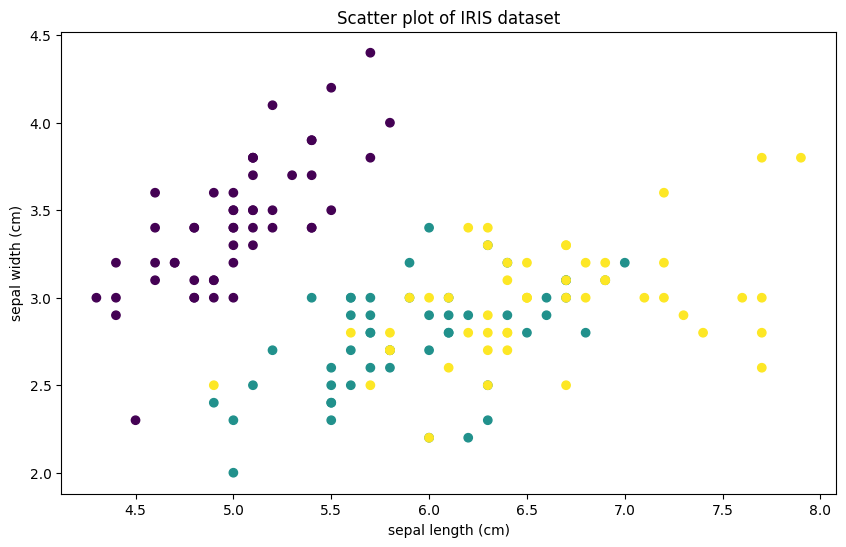

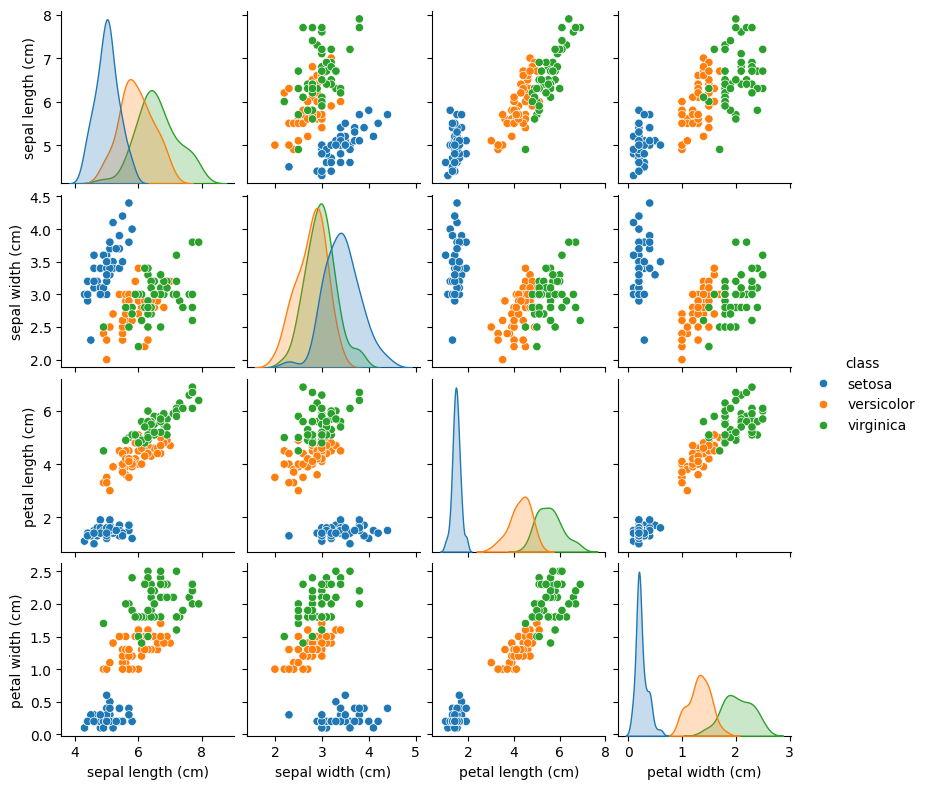

In [ ]:
# 1- Load IRIS and MNIST fashion datasets from Keras.

# a. IRIS dataset

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
import numpy as np
from sklearn.decomposition import KernelPCA
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

df = pd.DataFrame()

iris = load_iris()
print(iris.data.shape)


df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df["target"] = iris.target
df["class"] = iris.target_names[iris.target]
df.head()

df.isnull().sum() # check for missing values
df.value_counts("class") # check class distribution

plt.figure(figsize=(10, 6))
plt.scatter(df.iloc[:, 0], df.iloc[:, 1], c=df["target"], cmap='viridis')
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.title("Scatter plot of IRIS dataset")

plt.show()

# importing packages
import seaborn as sns
import matplotlib.pyplot as plt


sns.pairplot(df.drop(['target'], axis = 1), 
             hue='class', height=2)

Train: (120, 4) (120,)
Test:  (30, 4) (30,)


c:\Users\nisse\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 10)             │            50 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 20)             │           220 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 3)              │            63 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333 (1.30 KB)

 Trainable params: 333 (1.30 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.3229 - loss: 1.0633 - val_accuracy: 0.5833 - val_loss: 1.0103
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5417 - loss: 1.0035 - val_accuracy: 0.7083 - val_loss: 0.9522
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6250 - loss: 0.9483 - val_accuracy: 0.7500 - val_loss: 0.8909
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6771 - loss: 0.8885 - val_accuracy: 0.8750 - val_loss: 0.8325
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7188 - loss: 0.8279 - val_accuracy: 0.8750 - val_loss: 0.7702
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7917 - loss: 0.7675 - val_accuracy: 0.9167 - val_loss: 0.7120
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8125 - loss: 0.7112 - val_accuracy: 0.9583 - val_loss: 0.6573
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8646 - loss: 0.6556 - val_accuracy: 0.9167 - val_los

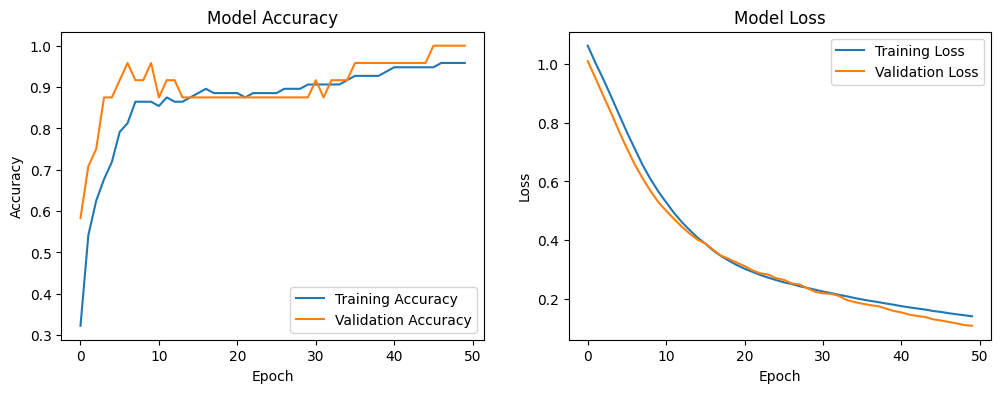

In [ ]:
# build and train neural network model for IRIS dataset

# Features (4 st) + labels (0,1,2)
X = df[iris.feature_names].values
y = df["target"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   #makes sure class distribution is the same in train and test sets
)

print("Train:", X_train.shape, y_train.shape)
print("Test: ", X_test.shape, y_test.shape)

# Standardize the data

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# One-hot encode the labels
encoder = OneHotEncoder(sparse_output=False)
y_train_encoded = encoder.fit_transform(y_train.reshape(-1, 1))
y_test_encoded = encoder.transform(y_test.reshape(-1, 1))

# Build the model
def build_model():
    model = Sequential()
    model.add(Dense(10, activation='relu', input_shape=(X_train.shape[1],)))
    model.add(Dense(20, activation='relu'))
    model.add(Dense(3, activation='softmax'))  # 3 classes in IRIS dataset

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model = build_model()
model.summary()

history = model.fit(
    X_train_scaled, y_train_encoded,
    validation_split=0.2,
    epochs=50,
    batch_size=8,
    verbose=1
)

# Evaluate the model
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test_encoded, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

Trial 20 Complete [00h 00m 05s]
val_loss: 0.6159212589263916

Best val_loss So Far: 0.048224687576293945
Total elapsed time: 00h 01m 44s


c:\Users\nisse\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 56)             │           952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 56)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 40)             │         2,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 40)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           123 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,435 (13.42 KB)

 Trainable params: 3,435 (13.42 KB)

 Non-trainable params: 0 (0.00 B)

Tuned Test Accuracy: 0.9467
Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9833 - loss: 0.0762 - val_accuracy: 0.8667 - val_loss: 0.2990
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9500 - loss: 0.0920 - val_accuracy: 1.0000 - val_loss: 0.0106
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9333 - loss: 0.2578 - val_accuracy: 0.8000 - val_loss: 0.6276
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9500 - loss: 0.1515 - val_accuracy: 0.8667 - val_loss: 0.1546
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9667 - loss: 0.1104 - val_accuracy: 1.0000 - val_loss: 0.0797
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.0391 - val_accuracy: 0.8667 - val_loss: 0.1910
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9833 - loss: 0.1003 - val_accuracy: 0.8667 - val_loss: 0.2365
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9667 - loss: 0.0562 - val_accuracy

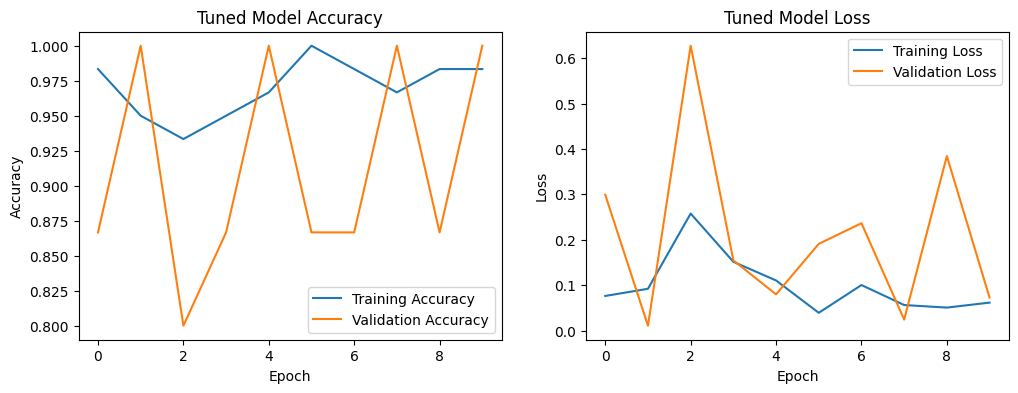

In [ ]:
# tuning neural network

"""
since we reached 100% validated accuracy on IRIS dataset with a simple model
we decrease the training set size to 50% to make things a little harder 
we then try to tune the model with Keras Tuner. we focus on minimizing the validation loss.
"""
keras.backend.clear_session()

X = df[iris.feature_names].values
y = df["target"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.5,
    random_state=42,
    stratify=y   #makes sure class distribution is the same in train and test sets
)

# Standardize the data

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# One-hot encode the labels
encoder = OneHotEncoder(sparse_output=False)
y_train_encoded = encoder.fit_transform(y_train.reshape(-1, 1))
y_test_encoded = encoder.transform(y_test.reshape(-1, 1))


def build_model(hp):
    model = Sequential()
    act = hp.Choice("activation", values=["relu", "tanh", "sigmoid"])
    dr = hp.Float("dropout", min_value=0.0, max_value=0.5, step=0.1)
    model.add(Dense(16, activation=act, input_shape=(X_train_scaled.shape[1],)))
    num_layers = hp.Int('num_layers', 1, 3)
    for i in range(num_layers):
        units = hp.Int(f'units_{i}', min_value=8, max_value=64, step=8)
        model.add(Dense(units, activation=act))

        if dr > 0:
            model.add(layers.Dropout(dr))
    model.add(Dense(3, activation='softmax'))  # 3 classes in IRIS dataset
    lr = hp.Choice("lr", values=[1e-1,1e-2, 1e-3, 3e-4])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

early = keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

import keras_tuner as kt

tuner = kt.RandomSearch(
    build_model,
    objective=kt.Objective("val_loss", direction="min"),
    max_trials=20,
    overwrite=True,
    directory="C:/Users/nisse",
    project_name="IRIS_tuning",
)

tuner.search(
    X_train_scaled, y_train_encoded,
    epochs=15,
    validation_split=0.2,
    callbacks=[early],
    batch_size=28

)

best_model = tuner.get_best_models(num_models=1)[0]
best_hyperparameters = tuner.get_best_hyperparameters(num_trials=1)[0]
best_model.summary()
test_loss, test_accuracy = best_model.evaluate(X_test_scaled, y_test_encoded, verbose=0)
print(f"Tuned Test Accuracy: {test_accuracy:.4f}")

history = best_model.fit(
    X_train_scaled, y_train_encoded,
    validation_split=0.2,
    epochs=10,
    
    batch_size=8,
    verbose=1
)   

best_model.save("best_iris_model.keras", overwrite=True)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Tuned Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Tuned Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()


(60000, 784) (10000, 784)


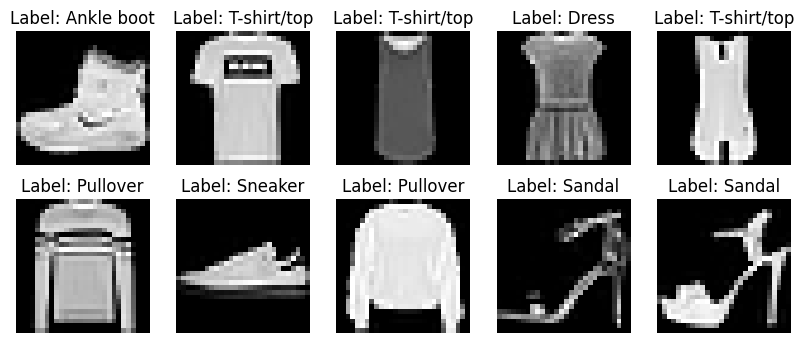

In [ ]:
# 1- Load IRIS and MNIST fashion datasets from Keras.

# a. MNIST fashion dataset
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.datasets import fashion_mnist
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data() # Load Fashion-MNIST dataset /784 dimensions

X_train = x_train.reshape(-1, 28*28).astype(np.float32) / 255.0 # Normalizing the data
X_test  = x_test.reshape(-1, 28*28).astype(np.float32) / 255.0

print(X_train.shape, X_test.shape)

lbls = {0: 'T-shirt/top', 1: 'Trouser', 2: 'Pullover', 3: 'Dress', 4: 'Coat',
        5: 'Sandal', 6: 'Shirt', 7: 'Sneaker', 8: 'Bag', 9: 'Ankle boot'}

plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.axis('off')
    plt.title(f'Label: {lbls[y_train[i]]}')



c:\Users\nisse\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8036 - loss: 0.5564 - val_accuracy: 0.8519 - val_loss: 0.4118
Epoch 2/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8559 - loss: 0.4006 - val_accuracy: 0.8693 - val_loss: 0.3595
Epoch 3/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8673 - loss: 0.3604 - val_accuracy: 0.8766 - val_loss: 0.3419
Epoch 4/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8767 - loss: 0.3374 - val_accuracy: 0.8692 - val_loss: 0.3570
Epoch 5/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8835 - loss: 0.3181 - val_accuracy: 0.8764 - val_loss: 0.3427
Epoch 6/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8861 - loss: 0.3043 - val_accuracy: 0.8810 - val_loss: 0.3264
Epoch 7/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8917 - loss: 0.2914 - val_accuracy: 0.8685 - val_loss: 0.3624
Epoch 8/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8961 - loss: 0.2782 - 

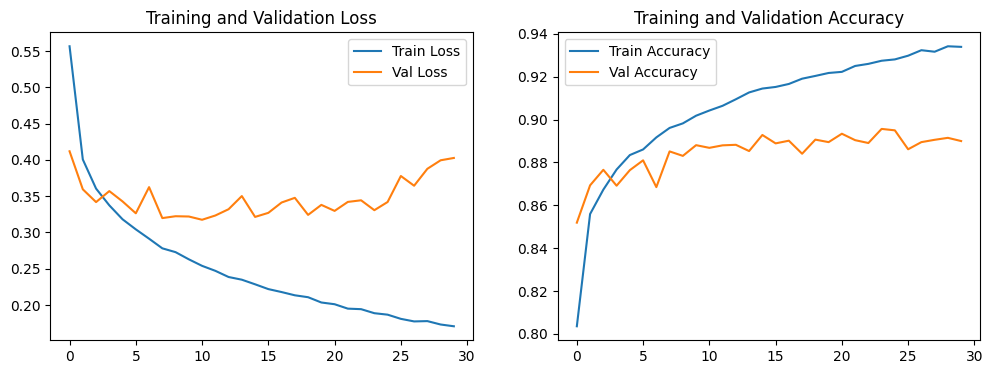

In [ ]:
# 2- Build and train a neural network for classifying the loaded labeled datasets.

model = keras.Sequential([
    keras.layers.InputLayer(input_shape=(28*28,)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(10, activation='softmax')
])
model.summary()

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])
model.fit(X_train, y_train, epochs=30, batch_size=32, validation_split=0.2)

history = model.history.history
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history['loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Training and Validation Loss')

plt.subplot(1,2,2)
plt.plot(history['accuracy'], label='Train Accuracy')
plt.plot(history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')

test_loss, test_acc = model.evaluate(X_test, y_test)
print('\nTest accuracy with original data:', test_acc)

Trial 20 Complete [00h 01m 18s]
val_accuracy: 0.8762500286102295

Best val_accuracy So Far: 0.8924166560173035
Total elapsed time: 00h 42m 19s
Best hyperparameters:
num_layers : 1
units_0 : 256
activation : sigmoid
dropout : 0.30000000000000004
lr : 0.001
units_1 : 256


c:\Users\nisse\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Test accuracy: 0.8815000057220459


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
1715/1715 - 8s - 4ms/step - accuracy: 0.9074 - loss: 0.2489 - val_accuracy: 0.8910 - val_loss: 0.3021
Epoch 2/30
1715/1715 - 5s - 3ms/step - accuracy: 0.9088 - loss: 0.2446 - val_accuracy: 0.8949 - val_loss: 0.2937
Epoch 3/30
1715/1715 - 5s - 3ms/step - accuracy: 0.9113 - loss: 0.2371 - val_accuracy: 0.8936 - val_loss: 0.2994
Epoch 4/30
1715/1715 - 5s - 3ms/step - accuracy: 0.9126 - loss: 0.2336 - val_accuracy: 0.8917 - val_loss: 0.2997
Epoch 5/30
1715/1715 - 5s - 3ms/step - accuracy: 0.9137 - loss: 0.2297 - val_accuracy: 0.8949 - val_loss: 0.2942
Epoch 6/30
1715/1715 - 5s - 3ms/step - accuracy: 0.9157 - loss: 0.2242 - val_accuracy: 0.8933 - val_loss: 0.2982
Epoch 7/30
1715/1715 - 5s - 3ms/step - accuracy: 0.9165 - loss: 0.2208 - val_accuracy: 0.8920 - val_loss: 0.3046
Epoch 8/30
1715/1715 - 5s - 3ms/step - accuracy: 0.9192 - loss: 0.2152 - val_accuracy: 0.8926 - val_loss: 0.3041
Epoch 9/30
1715/1715 - 5s - 3ms/step - accuracy: 0.9203 - loss: 0.2119 - val_accuracy: 0.8971 - 

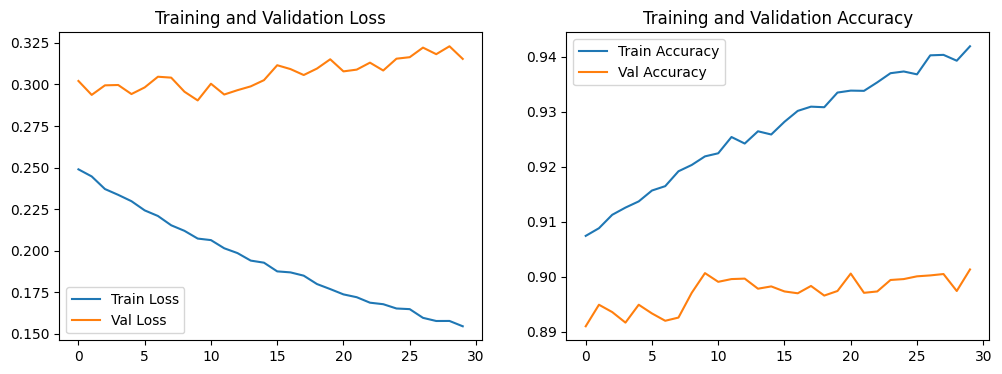

In [ ]:
# 3- Tune the hyperparameters (including hidden layer size and activation functions). What else can be tuned?

keras.backend.clear_session()
import keras_tuner as kt
from tensorflow.keras import layers

def build_model(hp):
    model = keras.Sequential()
    model.add(layers.Input(shape=(784,)))

    # Tune number of hidden layers
    num_layers = hp.Int("num_layers", min_value=1, max_value=5, step=1)

    for i in range(num_layers):
        units = hp.Choice(f"units_{i}", values=[32, 64, 128, 256, 784])
        act = hp.Choice("activation", values=["relu", "tanh", "sigmoid"])
        model.add(layers.Dense(units, activation=act))

        dr = hp.Float("dropout", min_value=0.0, max_value=0.5, step=0.1)
        if dr > 0:
            model.add(layers.Dropout(dr))

    model.add(layers.Dense(10, activation="softmax"))

    lr = hp.Choice("lr", values=[1e-2, 1e-3, 3e-4])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

import os, shutil

tuner = kt.RandomSearch(
    build_model,
    objective="val_accuracy",
    max_trials=20,
    overwrite=True,
    directory="C:/Users/nisse",
    project_name="Mnist_fashion_tuning",
)



early = keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

tuner.search(
    X_train, y_train,
    epochs=15,
    validation_split=0.2,
    callbacks=[early],
    batch_size=28

)

best_hp = tuner.get_best_hyperparameters(1)[0]
print("Best hyperparameters:")
for k in best_hp.values:
    print(k, ":", best_hp.values[k])

best_model = tuner.get_best_models(1)[0]
test_loss, test_acc = best_model.evaluate(X_test, y_test, verbose=0)
print("Test accuracy:", test_acc)

best_model.summary()

best_model.save("best_mnist_fashion_model.h5")

history = best_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=28,
    verbose=2
)


plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Training and Validation Loss')

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')

plt.show()






In [ ]:
# 6- Practice saving and loading the trained model

import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import load_model

iris = load_iris()
X = iris.data.astype("float32")
y = iris.target.astype("int32")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

MODEL_PATH = r"C:\Users\nisse\OneDrive - Högskolan Väst\DIL700\Assignment 2\best_iris_model.keras"

# compile=False avoids errors if the model was saved with a different loss/metrics setup
model = load_model(MODEL_PATH, compile=False)

model.compile(
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
loss, acc = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Loaded model test accuracy: {acc:.4f}")
print(f"Loaded model test loss:     {loss:.4f}")

model.summary()



Loaded model test accuracy: 0.9333
Loaded model test loss:     0.1391


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 56)             │           952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 56)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 40)             │         2,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 40)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           123 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,435 (13.42 KB)

 Trainable params: 3,435 (13.42 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_mnist = load_model(
    r"C:\Users\nisse\OneDrive - Högskolan Väst\DIL700\Assignment 2\best_mnist_fashion_model.h5"
)

model_mnist.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,532 (795.05 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

I can load the model. I do however do not have a scaler saved meaning I can not run the model directly. This also means that the outcome may differ. I could also of course save the scaler but for the next time I will try to normalize inside the model to get rid of this problem. 

In [ ]:
# 1- Load California housing dataset and split it to training and testing datasets.

import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

np.random.seed(42)  # For reproducibility

df = pd.DataFrame(fetch_california_housing(as_frame=True).frame)
X = df.drop("MedHouseVal", axis=1).values.astype("float32")
y = df["MedHouseVal"].values.astype("float32")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

df.head()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
# 2- Build and train a neural network for price prediction. 
# Tune the hyperparameters and discuss the results.

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers
from tensorflow import keras
import keras_tuner as kt


norm = layers.Normalization()
norm.adapt(X_train) # normalizing only the training data

def build_model(hp):
    model = Sequential()
    model.add(layers.Input(shape=(X_train.shape[1],)))
    model.add(norm) #data is scaled inside the model instead of using standarscaler

    n_layers = hp.Int("n_layers", min_value=1, max_value=5, step=1)
    activation = hp.Choice("activation", values=["relu", "tanh", "elu", "sigmoid"])
    dropout = hp.Float("dropout", min_value=0.0, max_value=0.5, step=0.1)

    for i in range(n_layers):
        units = hp.Int(f"units_{i}", min_value=16, max_value=256, step=16)
        model.add(layers.Dense(units, activation=activation))
        if dropout > 0:
            model.add(layers.Dropout(dropout))
    
    model.add(layers.Dense(1))  # Output layer

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-4),
        loss="mse",
        metrics=["mae"]
    )
    return model

early = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint = keras.callbacks.ModelCheckpoint(
    filepath="best_california_tuned_lr4.keras",
    monitor="val_loss",
    save_best_only=True
)

tuner = kt.RandomSearch(
    build_model,
    objective=kt.Objective("val_loss", direction="min"),
    max_trials=25,
    overwrite=True,
    directory="C:/Users/nisse",
    project_name="CA_housing_tuning"
)

tuner.search(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=hp_batch if False else 32, 
    callbacks=[early, checkpoint],
    verbose=2
)

best_hp = tuner.get_best_hyperparameters(1)[0]
print("\nBest hyperparameters:")
for k, v in best_hp.values.items():
    print(f"{k}: {v}")

best_model = tuner.get_best_models(1)[0]
best_model.summary()

test_loss, test_mae = best_model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest MSE: {test_loss:.4f}")
print(f"Test MAE: {test_mae:.4f}")        

Trial 25 Complete [00h 01m 14s]
val_loss: 0.393429696559906

Best val_loss So Far: 0.2881695330142975
Total elapsed time: 00h 22m 19s

Best hyperparameters:
n_layers: 5
activation: tanh
dropout: 0.0
units_0: 176
units_1: 48
units_2: 160
units_3: 240
units_4: 64


c:\Users\nisse\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 26 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 8)              │            17 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 176)            │         1,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 48)             │         8,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 160)            │         7,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 240)            │        38,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        15,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 72,066 (281.51 KB)

 Trainable params: 72,049 (281.44 KB)

 Non-trainable params: 17 (72.00 B)


Test MSE: 0.2816
Test MAE: 0.3665


Epoch 1/200
413/413 - 3s - 7ms/step - loss: 0.2594 - mae: 0.3440 - val_loss: 0.2983 - val_mae: 0.3688
Epoch 2/200
413/413 - 1s - 3ms/step - loss: 0.2577 - mae: 0.3437 - val_loss: 0.2881 - val_mae: 0.3626
Epoch 3/200
413/413 - 1s - 3ms/step - loss: 0.2574 - mae: 0.3425 - val_loss: 0.2904 - val_mae: 0.3601
Epoch 4/200
413/413 - 1s - 3ms/step - loss: 0.2553 - mae: 0.3421 - val_loss: 0.2846 - val_mae: 0.3654
Epoch 5/200
413/413 - 1s - 3ms/step - loss: 0.2545 - mae: 0.3409 - val_loss: 0.2882 - val_mae: 0.3626
Epoch 6/200
413/413 - 1s - 3ms/step - loss: 0.2553 - mae: 0.3418 - val_loss: 0.2992 - val_mae: 0.3665
Epoch 7/200
413/413 - 1s - 3ms/step - loss: 0.2540 - mae: 0.3414 - val_loss: 0.2874 - val_mae: 0.3696
Epoch 8/200
413/413 - 1s - 3ms/step - loss: 0.2531 - mae: 0.3403 - val_loss: 0.2812 - val_mae: 0.3657
Epoch 9/200
413/413 - 1s - 2ms/step - loss: 0.2517 - mae: 0.3393 - val_loss: 0.2771 - val_mae: 0.3566
Epoch 10/200
413/413 - 1s - 2ms/step - loss: 0.2508 - mae: 0.3378 - val_loss: 0.28

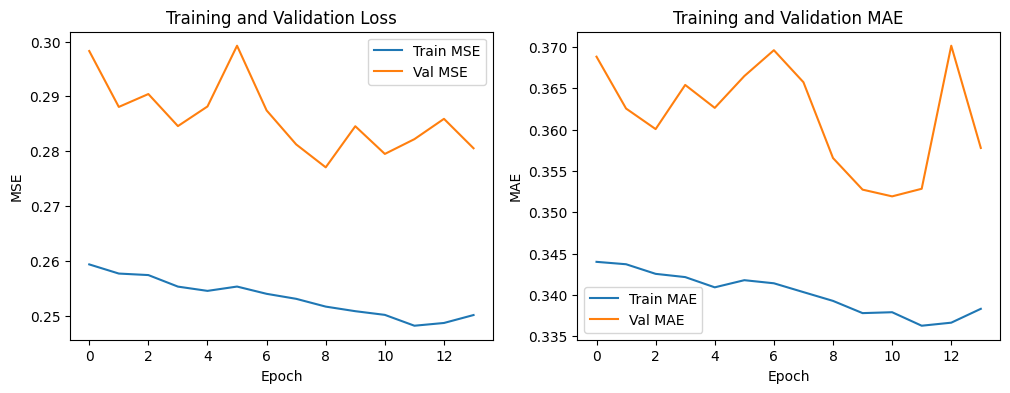

In [ ]:
# 3- Plot the network history.

history = best_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    callbacks=[early],
    verbose=2
)

import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

# Loss (MSE)
plt.subplot(1,2,1)
plt.plot(history.history["loss"], label="Train MSE")
plt.plot(history.history["val_loss"], label="Val MSE")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Training and Validation Loss")
plt.legend()

# MAE
plt.subplot(1,2,2)
plt.plot(history.history["mae"], label="Train MAE")
plt.plot(history.history["val_mae"], label="Val MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("Training and Validation MAE")
plt.legend()

plt.show()


In [ ]:
# Same as above but different learning rate

keras.backend.clear_session() #clears previous weights from memory for a fresh start

norm = layers.Normalization()
norm.adapt(X_train) # normalizing only the training data

def build_model(hp):
    model = Sequential()
    model.add(layers.Input(shape=(X_train.shape[1],)))
    model.add(norm) #data is scaled inside the model instead of using standarscaler

    n_layers = hp.Int("n_layers", min_value=1, max_value=5, step=1)
    activation = hp.Choice("activation", values=["relu", "tanh", "elu", "sigmoid"])
    dropout = hp.Float("dropout", min_value=0.0, max_value=0.5, step=0.1)

    for i in range(n_layers):
        units = hp.Int(f"units_{i}", min_value=16, max_value=256, step=16)
        model.add(layers.Dense(units, activation=activation))
        if dropout > 0:
            model.add(layers.Dropout(dropout))
    
    model.add(layers.Dense(1))  # Output layer

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="mse",
        metrics=["mae"]
    )
    return model

early = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint = keras.callbacks.ModelCheckpoint(
    filepath="best_california_tuned_lr3.keras",
    monitor="val_loss",
    save_best_only=True
)

tuner = kt.RandomSearch(
    build_model,
    objective=kt.Objective("val_loss", direction="min"),
    max_trials=25,
    overwrite=True,
    directory="C:/Users/nisse",
    project_name="CA_housing_tuning"
)

tuner.search(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=hp_batch if False else 32, 
    callbacks=[early, checkpoint],
    verbose=2
)

best_hp = tuner.get_best_hyperparameters(1)[0]
print("\nBest hyperparameters:")
for k, v in best_hp.values.items():
    print(f"{k}: {v}")

best_model = tuner.get_best_models(1)[0]
best_model.summary()

test_loss, test_mae = best_model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest MSE: {test_loss:.4f}")
print(f"Test MAE: {test_mae:.4f}")        

Trial 25 Complete [00h 01m 08s]
val_loss: 0.37165898084640503

Best val_loss So Far: 0.2740376591682434
Total elapsed time: 00h 18m 26s

Best hyperparameters:
n_layers: 5
activation: elu
dropout: 0.0
units_0: 208
units_1: 16
units_2: 96
units_3: 160
units_4: 96


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 8)              │            17 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 208)            │         1,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │         3,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 96)             │         1,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 160)            │        15,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 96)             │        15,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            97 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,938 (148.20 KB)

 Trainable params: 37,921 (148.13 KB)

 Non-trainable params: 17 (72.00 B)


Test MSE: 0.2761
Test MAE: 0.3486


Epoch 1/200
413/413 - 4s - 9ms/step - loss: 0.2596 - mae: 0.3470 - val_loss: 0.2910 - val_mae: 0.3900
Epoch 2/200
413/413 - 1s - 3ms/step - loss: 0.2569 - mae: 0.3472 - val_loss: 0.2857 - val_mae: 0.3645
Epoch 3/200
413/413 - 1s - 3ms/step - loss: 0.2566 - mae: 0.3436 - val_loss: 0.2796 - val_mae: 0.3473
Epoch 4/200
413/413 - 1s - 3ms/step - loss: 0.2573 - mae: 0.3460 - val_loss: 0.2754 - val_mae: 0.3550
Epoch 5/200
413/413 - 1s - 3ms/step - loss: 0.2512 - mae: 0.3415 - val_loss: 0.2909 - val_mae: 0.3865
Epoch 6/200
413/413 - 1s - 2ms/step - loss: 0.2502 - mae: 0.3410 - val_loss: 0.2869 - val_mae: 0.3586
Epoch 7/200
413/413 - 1s - 2ms/step - loss: 0.2466 - mae: 0.3397 - val_loss: 0.2898 - val_mae: 0.3574
Epoch 8/200
413/413 - 1s - 2ms/step - loss: 0.2462 - mae: 0.3372 - val_loss: 0.2888 - val_mae: 0.3619
Epoch 9/200
413/413 - 1s - 2ms/step - loss: 0.2486 - mae: 0.3405 - val_loss: 0.3049 - val_mae: 0.3863


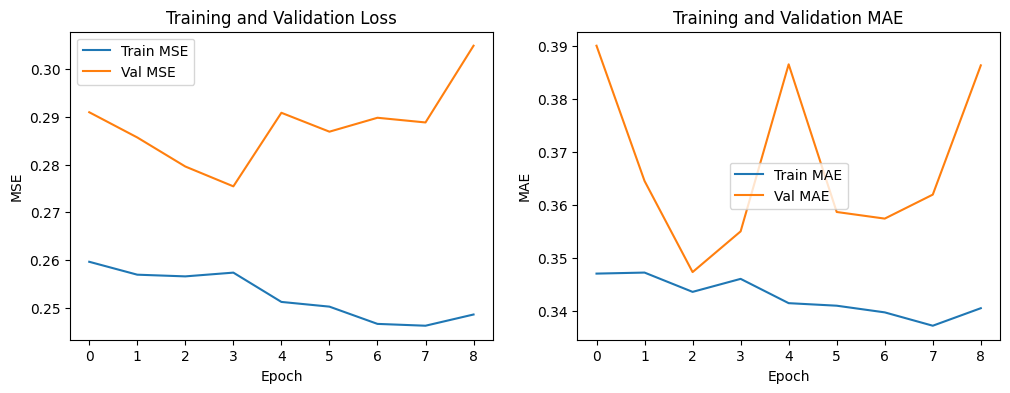

In [ ]:
# 3- Plot the network history.

history = best_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    callbacks=[early],
    verbose=2
)

import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

# Loss (MSE)
plt.subplot(1,2,1)
plt.plot(history.history["loss"], label="Train MSE")
plt.plot(history.history["val_loss"], label="Val MSE")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Training and Validation Loss")
plt.legend()

# MAE
plt.subplot(1,2,2)
plt.plot(history.history["mae"], label="Train MAE")
plt.plot(history.history["val_mae"], label="Val MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("Training and Validation MAE")
plt.legend()

plt.show()


The NN built with the lower learning rate of 1*10^-4 performed a validation MAE little over 0.35 at the 10th epoch
The NN built with the higher learning rate of 1*10^-3 performed a validation MAE of 0.35 at the 3rd epoch

The neural network with the higher training rate took about 18 minutes to train vs about 22 with the one with lower rate. We can not say that one approach gives better precision than the other since the results are more or less the same.

The conclusion that can be drawn is that a lower training rate is not neccessarily better. it does take more time and with lower rate in combination with early stopping we risk stopping before reaching a better minima. That could be the reason the NN with the lower learning rate did not perform better.


In [ ]:
# practice loading the model.

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
import keras

california = fetch_california_housing()
X = california.data.astype("float32")
y = california.target.astype("float32")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model_path = r"C:/Users/nisse/OneDrive - Högskolan Väst/DIL700/Assignment 2/best_california_tuned_lr3.keras"

model = keras.models.load_model(model_path, compile=False)

model.summary()

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",
    metrics=["mae"]
)

loss, mae = model.evaluate(X_test, y_test, verbose=0)

print(f"Loaded model test MAE:  {mae:.4f}")
print(f"Loaded model test loss: {loss:.4f}")




Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 8)              │            17 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 192)            │        49,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 48)             │         9,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 160)            │         7,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 160)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 68,930 (269.26 KB)

 Trainable params: 68,913 (269.19 KB)

 Non-trainable params: 17 (72.00 B)

Loaded model test MAE:  0.4124
Loaded model test loss: 0.3523
